In [43]:
#!/usr/bin/env python
# coding: utf-8

In[2]:

In [44]:
import scipy.io
import os
import sys
import numpy as np
from scipy.interpolate import interp1d
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sbi import utils as sbi_utils
from sbi.inference import SNPE
from sbi.utils.get_nn_models import posterior_nn
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [45]:
name_format = "GBM_test"
print("Note: use results8.mat which has 10000 datasets; B only has positive Z values")
file_path = os.path.join('MATLAB_DATA', 'results8.mat')  # Replace with your actual file path
def generate_filename(base_name, extension):
    return f"{name_format}_{base_name}.{extension}"

Note: use results8.mat which has 10000 datasets; B only has positive Z values


In [46]:
import os
import scipy.io
import h5py
import numpy as np
from scipy.interpolate import interp1d

In [47]:
h5_file_numbers = {3, 6, 7, 9}

Function to load data from .h5 file

In [48]:
def load_h5_data(file_path):
    with h5py.File(file_path, 'r') as hdf:
        results_group = hdf['results']
        B_MAG_refs = results_group['B_MAG'][()]
        EDC_MAG_refs = results_group['EDC_MAG'][()]
        X_refs = results_group['X'][()]
        I_refs = results_group['I'][()]
        B_MAG_raw = [hdf[ref][()] for ref in B_MAG_refs.flatten()]
        EDC_MAG_raw = [hdf[ref][()] for ref in EDC_MAG_refs.flatten()]
        X_raw = [hdf[ref][()] for ref in X_refs.flatten()]
        I_raw = [hdf[ref][()] for ref in I_refs.flatten()]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw

Function to load data from .mat file

In [49]:
def load_mat_data(file_path):
    mat_contents = scipy.io.loadmat(file_path)
    results = mat_contents['results']
    B_MAG_raw = [result['B_MAG'][0] for result in results[0]]
    EDC_MAG_raw = [result['EDC_MAG'][0] for result in results[0]]
    X_raw = [result['X'][0] for result in results[0]]  # Scaling X values
    I_raw = [result['I'][0] for result in results[0]]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw

Function to resample and smooth data

In [50]:
def resample_and_smooth(X, I, new_length):
    X_new = np.linspace(6562.3, 6563.3, num=new_length)
    f = interp1d(X, I, kind='cubic', fill_value="extrapolate")
    I_new = f(X_new)
    return X_new, I_new

Function to process data

In [51]:
def process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw, fixed_length=1200):
    X_data, I_data, B_MAG_data, EDC_MAG_data = [], [], [], []
    for i in range(len(X_raw)):
        X = np.squeeze(X_raw[i])
        I = np.squeeze(I_raw[i])
        B = np.squeeze(B_MAG_raw[i])
        EDC = np.squeeze(EDC_MAG_raw[i])
        X_scaled = X * 10**10
        X_resampled, I_resampled = resample_and_smooth(X_scaled, I, fixed_length)
        X_data.append(X_resampled)
        I_data.append(I_resampled)
        B_MAG_data.append(B)
        EDC_MAG_data.append(EDC)
    return np.array(B_MAG_data), np.array(EDC_MAG_data), np.array(X_data), np.array(I_data)

Main function to determine the type of file and load data accordingly

In [52]:
def load_and_process_file(file_path):
    file_name = os.path.basename(file_path)
    
    # Extract the file number (e.g., results1, results5, etc.)
    file_number = int(file_name.lstrip('results').rstrip('.mat'))
    
    if file_number in h5_file_numbers:
        # It's an HDF5 file
        print(f"Processing {file_name} as an HDF5 file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_h5_data(file_path)
    else:
        # It's a standard .mat file
        print(f"Processing {file_name} as a .mat file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_mat_data(file_path)
    
    # Process the loaded data
    B_MAG_data, EDC_MAG_data, X_data, I_data = process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw)
    
    return B_MAG_data, EDC_MAG_data, X_data, I_data

Example usage

In [53]:
B_MAG_data, EDC_MAG_data, X_data, I_data = load_and_process_file(file_path)

Processing results8.mat as a .mat file...


Data is now loaded and processed.

In [54]:
print("Data processing completed.")

Data processing completed.


In [55]:
means = np.mean(I_data, axis=0)
stds = np.std(I_data, axis=0)

In[15]:

In [56]:
start_index = 0
end_index = I_data.shape[1] - 1

In[16]:

In [57]:
for i in range(I_data.shape[1]):
    if stds[i] >= 0.01:
        start_index = i
        break

In[17]:

In [58]:
for i in range(I_data.shape[1] - 1, -1, -1):
    if stds[i] >= 0.01:
        end_index = i
        break

In[18]:

In [59]:
I_data_filtered = I_data[:, start_index:end_index + 1]
means_filtered = means[start_index:end_index + 1]
stds_filtered = stds[start_index:end_index + 1]
print(f"Data filtered from column {start_index} to {end_index}.")

Data filtered from column 94 to 1103.


Normalize the data

In[19]:

In [60]:
normalized_I = (I_data_filtered - means_filtered) / stds_filtered

In [61]:
input_data = normalized_I

Normalize target and target data

In [62]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Assuming B_MAG_data and EDC_MAG_data are loaded as NumPy arrays
# B3 is B_MAG_data[:, 2], and EDC_MAG_data consists of E1, E2, E3
B3 = B_MAG_data[:, 2].reshape(-1, 1)  # B3 component
E1 = EDC_MAG_data[:, 0].reshape(-1, 1)  # E1 component
E2 = EDC_MAG_data[:, 1].reshape(-1, 1)  # E2 component
E3 = EDC_MAG_data[:, 2].reshape(-1, 1)  # E3 component

# Create separate MinMaxScaler instances for each component
scaler_B3 = MinMaxScaler(feature_range=(0, 1))
scaler_E1 = MinMaxScaler(feature_range=(0, 1))
scaler_E2 = MinMaxScaler(feature_range=(0, 1))
scaler_E3 = MinMaxScaler(feature_range=(0, 1))

# Fit and transform each component separately
B3_scaled = scaler_B3.fit_transform(B3)
E1_scaled = scaler_E1.fit_transform(E1)
E2_scaled = scaler_E2.fit_transform(E2)
E3_scaled = scaler_E3.fit_transform(E3)

# Recombine the scaled components back into target_data
target_data = np.hstack((B3_scaled, E1_scaled, E2_scaled, E3_scaled))

# Now, target_data_scaled contains B3, E1, E2, E3 all scaled between 0 and 1


In [63]:
target_data_train, target_data_test, input_data_train, input_data_test = train_test_split(
    target_data, input_data, test_size=0.2, random_state=42
)

In[28]:

In [64]:
print("Data organized.", flush=True)

Data organized.


In[ ]:

In [65]:
from sklearn.experimental import enable_hist_gradient_boosting  
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

gbm = HistGradientBoostingRegressor(
    max_iter=1000,            # Maximum number of boosting iterations
    learning_rate=0.0005,      # Learning rate
    max_depth=8,             # Maximum depth of the tree
    validation_fraction=0.2, # Fraction of the data to use for validation
    early_stopping=True,     # Early stopping flag
    tol=1e-4,                # Tolerance for stopping
    verbose=1,                # To monitor the training process
    random_state=42,
    loss='least_squares'
)

multi_gbm = MultiOutputRegressor(gbm)

# Train the model
multi_gbm.fit(input_data_train, target_data_train)

# Make predictions
y_pred = multi_gbm.predict(input_data_test)


Binning 0.052 GB of training data: 30.921 s
Binning 0.013 GB of validation data: 29.828 s
Fitting gradient boosted rounds:
[1/1000] 1 tree, 31 leaves, max depth = 7, train loss: 0.04245, val loss: 0.04131, in 8.061s
[2/1000] 1 tree, 31 leaves, max depth = 7, train loss: 0.04241, val loss: 0.04128, in 7.808s
[3/1000] 1 tree, 31 leaves, max depth = 7, train loss: 0.04238, val loss: 0.04124, in 7.986s
[4/1000] 1 tree, 31 leaves, max depth = 7, train loss: 0.04234, val loss: 0.04121, in 7.979s
[5/1000] 1 tree, 31 leaves, max depth = 7, train loss: 0.04231, val loss: 0.04117, in 8.029s
[6/1000] 1 tree, 31 leaves, max depth = 7, train loss: 0.04227, val loss: 0.04114, in 8.008s
[7/1000] 1 tree, 31 leaves, max depth = 7, train loss: 0.04223, val loss: 0.04110, in 7.826s
[8/1000] 1 tree, 31 leaves, max depth = 7, train loss: 0.04220, val loss: 0.04107, in 7.879s
[9/1000] 1 tree, 31 leaves, max depth = 7, train loss: 0.04216, val loss: 0.04104, in 8.007s
[10/1000] 

KeyboardInterrupt: 

In [ ]:
# import xgboost as xgb
# model = xgb.XGBRegressor(
#     n_estimators=1000,
#     learning_rate=0.01,
#     max_depth=7,
#     objective='reg:squarederror',
#     eval_metric='rmse',
#     early_stopping_rounds=10,
#     random_state=42
# )
# model.fit(input_data_train, target_data_train, eval_set=[(input_data_test, target_data_test)])

# y_pred = model.predict(input_data_test)

[0]	validation_0-rmse:0.28619
[1]	validation_0-rmse:0.28405
[2]	validation_0-rmse:0.28194
[3]	validation_0-rmse:0.27984
[4]	validation_0-rmse:0.27778
[5]	validation_0-rmse:0.27574
[6]	validation_0-rmse:0.27371
[7]	validation_0-rmse:0.27171
[8]	validation_0-rmse:0.26973
[9]	validation_0-rmse:0.26778
[10]	validation_0-rmse:0.26584
[11]	validation_0-rmse:0.26394
[12]	validation_0-rmse:0.26205
[13]	validation_0-rmse:0.26018
[14]	validation_0-rmse:0.25832
[15]	validation_0-rmse:0.25647
[16]	validation_0-rmse:0.25466
[17]	validation_0-rmse:0.25285
[18]	validation_0-rmse:0.25106
[19]	validation_0-rmse:0.24931
[20]	validation_0-rmse:0.24757
[21]	validation_0-rmse:0.24584
[22]	validation_0-rmse:0.24414
[23]	validation_0-rmse:0.24246
[24]	validation_0-rmse:0.24079
[25]	validation_0-rmse:0.23912
[26]	validation_0-rmse:0.23750
[27]	validation_0-rmse:0.23588
[28]	validation_0-rmse:0.23428
[29]	validation_0-rmse:0.23268
[30]	validation_0-rmse:0.23112
[31]	validation_0-rmse:0.22958
[32]	validation_0-

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=10,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [ ]:
print("Training done.", flush=True)

Training done.


In [ ]:
# import joblib

# # Define the path where the model will be saved
# model_save_path = os.path.join("/home/botingl/machine learning", generate_filename("trained_multioutput_gbm_model", "joblib"))

# # Save the trained model using joblib
# joblib.dump(model, model_save_path)
# print("Model saved successfully.")

Model saved successfully.


In [ ]:
# # Define the path where the model was saved
# model_load_path = os.path.join("/home/botingl/machine learning", generate_filename("trained_multioutput_gbm_model", "joblib"))

# # Load the model using joblib
# loaded_model = joblib.load(model_load_path)
# print(f"Model loaded from {model_load_path}")

Model loaded from /home/botingl/machine learning/GBM_test_trained_multioutput_gbm_model.joblib


In [ ]:
mae_test = mean_absolute_error(target_data_test, y_pred)
rmse_test = np.sqrt(mean_squared_error(target_data_test, y_pred))
r2_test = r2_score(target_data_test, y_pred)
nrmse_test = np.sqrt(np.mean((target_data_test - y_pred) ** 2)) / (target_data_test.max() - target_data_test.min())

In [ ]:
# metrics_train_file = os.path.join("/home/botingl/machine learning", generate_filename("evaluation_metrics_test", "txt"))
# with open(metrics_train_file, "w") as f:
#     f.write(f"Mean Absolute Error (MAE): {mae_test}\n")
#     f.write(f"Root Mean Squared Error (RMSE): {rmse_test}\n")
#     f.write(f"R^2 Score: {r2_test}\n")
#     f.write(f"Normalized RMSE (NRMSE): {nrmse_test}\n")

In [ ]:
# Evaluate the model performance for each variable
def evaluate_model(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, mae, r2

mse_B3, mae_B3, r2_B3 = evaluate_model(target_data_test[:, 0], y_pred[:, 0])
mse_E1, mae_E1, r2_E1 = evaluate_model(target_data_test[:, 1], y_pred[:, 1])
mse_E2, mae_E2, r2_E2 = evaluate_model(target_data_test[:, 2], y_pred[:, 2])
mse_E3, mae_E3, r2_E3 = evaluate_model(target_data_test[:, 3], y_pred[:, 3])

# Output the evaluation metrics
print(f"B3: MSE = {mse_B3}, MAE = {mae_B3}, R^2 = {r2_B3}")
print(f"E1: MSE = {mse_E1}, MAE = {mae_E1}, R^2 = {r2_E1}")
print(f"E2: MSE = {mse_E2}, MAE = {mae_E2}, R^2 = {r2_E2}")
print(f"E3: MSE = {mse_E3}, MAE = {mae_E3}, R^2 = {r2_E3}")


B3: MSE = 0.020668092573184766, MAE = 0.11808055007435787, R^2 = 0.7528310590287629
E1: MSE = 0.03236753511130291, MAE = 0.1500817632378904, R^2 = 0.6173862401718528
E2: MSE = 0.015214063477910395, MAE = 0.1005369512973582, R^2 = 0.8112248128661412
E3: MSE = 0.028523051845565965, MAE = 0.13940718169303176, R^2 = 0.6593576658102056


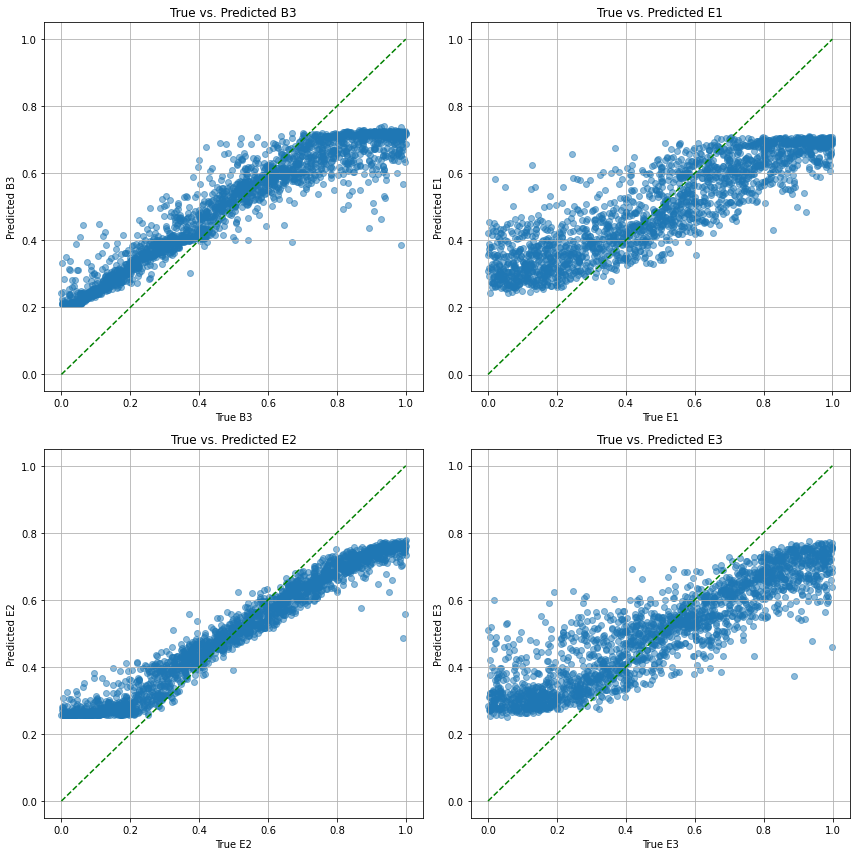

In [ ]:
# Function to plot true vs predicted values for each component
def plot_all_components(true_vals, pred_vals):
    plt.figure(figsize=(12, 12))
    
    # B3 plot
    plt.subplot(2, 2, 1)
    plt.scatter(true_vals[:, 0], pred_vals[:, 0], alpha=0.5)
    plt.plot([min(true_vals[:, 0]), max(true_vals[:, 0])], [min(true_vals[:, 0]), max(true_vals[:, 0])], 'g--')
    plt.xlabel('True B3')
    plt.ylabel('Predicted B3')
    plt.title('True vs. Predicted B3')
    plt.grid(True)
    
    # E1 plot
    plt.subplot(2, 2, 2)
    plt.scatter(true_vals[:, 1], pred_vals[:, 1], alpha=0.5)
    plt.plot([min(true_vals[:, 1]), max(true_vals[:, 1])], [min(true_vals[:, 1]), max(true_vals[:, 1])], 'g--')
    plt.xlabel('True E1')
    plt.ylabel('Predicted E1')
    plt.title('True vs. Predicted E1')
    plt.grid(True)
    
    # E2 plot
    plt.subplot(2, 2, 3)
    plt.scatter(true_vals[:, 2], pred_vals[:, 2], alpha=0.5)
    plt.plot([min(true_vals[:, 2]), max(true_vals[:, 2])], [min(true_vals[:, 2]), max(true_vals[:, 2])], 'g--')
    plt.xlabel('True E2')
    plt.ylabel('Predicted E2')
    plt.title('True vs. Predicted E2')
    plt.grid(True)
    
    # E3 plot
    plt.subplot(2, 2, 4)
    plt.scatter(true_vals[:, 3], pred_vals[:, 3], alpha=0.5)
    plt.plot([min(true_vals[:, 3]), max(true_vals[:, 3])], [min(true_vals[:, 3]), max(true_vals[:, 3])], 'g--')
    plt.xlabel('True E3')
    plt.ylabel('Predicted E3')
    plt.title('True vs. Predicted E3')
    plt.grid(True)
    
    plt.tight_layout()

    # figure_test_file = os.path.join("/home/botingl/machine learning", generate_filename("true_vs_predictions_test", "png"))
    # plt.savefig(figure_test_file, dpi=300, facecolor='white')

    plt.show()

# Plot all components in one figure
plot_all_components(target_data_test, y_pred)

